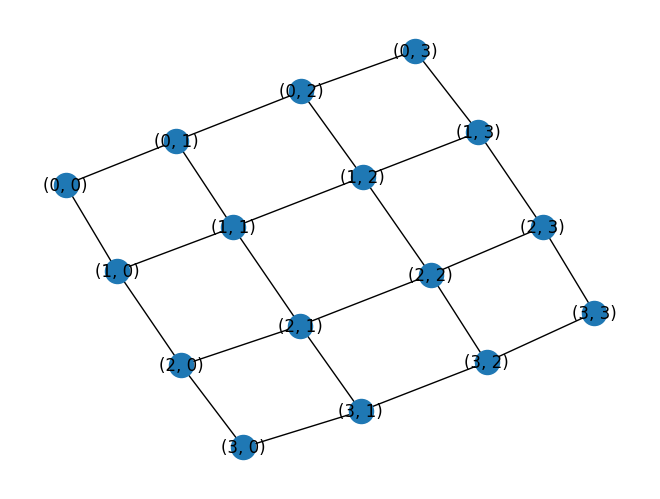

In [2]:
import random
import statistics as stats
import networkx as nx
import matplotlib.pyplot as plt

# graph topology options: k5, cycle, grid
TOPOLOGY = "grid"
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# build different graphs based on input topology
def build_graph(topology: str) -> nx.Graph:
    if topology == "k5":
        return nx.complete_graph(5)
    if topology == "cycle":
        return nx.cycle_graph(12)
    if topology == "grid":
        return nx.grid_2d_graph(4, 4)  # 4x4 grid

g = build_graph(TOPOLOGY)
nx.draw(g, with_labels=True)
plt.show()



In [ ]:
# input number of colours for the topology
NUM_COLORS = 5 if TOPOLOGY == "k5" else 2

palette = ["red", "blue", "green", "orange", "yellow"]

''' 
simple conflict counting function
reads node colours and returns count of edges with same colour at eaxh end
'''
def count_conflicts(graph, colouring):
    conflicts = 0
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicts += 1
    return conflicts

'''
record of conficting nodes
store node pairs that are coflicting in the 'conflicting' set
'''
def conflicting_nodes(graph, colouring):
    conflicting = set()
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicting.add(u)
            conflicting.add(v)
    return conflicting